# EDA

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv('./data/developer_burnout_dataset_7000.csv')

display(df.head())
display(df.info())

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


None

,Count,Percentage (%)
burnout_level,,
Medium,3485,50.801749
High,1782,25.976676
Low,1593,23.221574


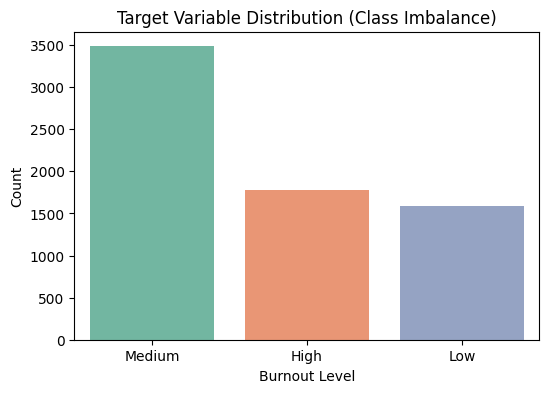

In [31]:
target_col = 'burnout_level'
if target_col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col, palette='Set2')
    plt.title('Target Variable Distribution (Class Imbalance)')
    plt.xlabel('Burnout Level')
    plt.ylabel('Count')
    
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percentages}))
else:
    print(f"Target column '{target_col}' not found. Check column names.")

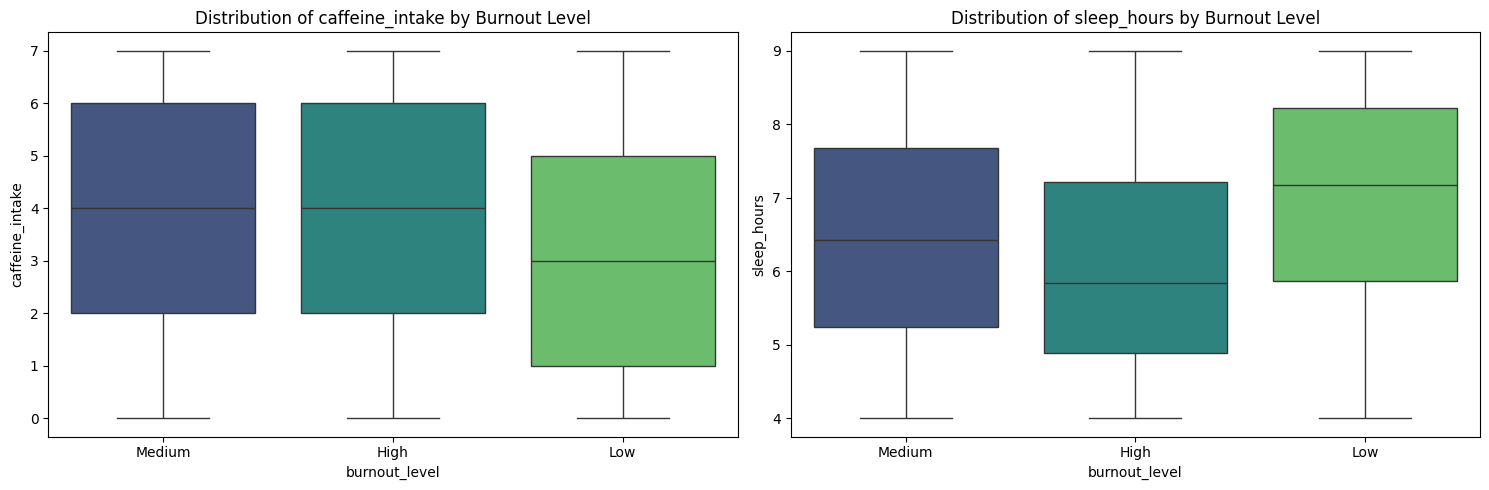

In [32]:
categorical_features = ['caffeine_intake', 'sleep_hours']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_features, 1):
    if col in df.columns:
        plt.subplot(1, 2, i)
        sns.boxplot(data=df, x=target_col, y=col, palette='viridis')
        plt.title(f'Distribution of {col} by Burnout Level')
        plt.ylabel(col)

plt.tight_layout()
plt.show()

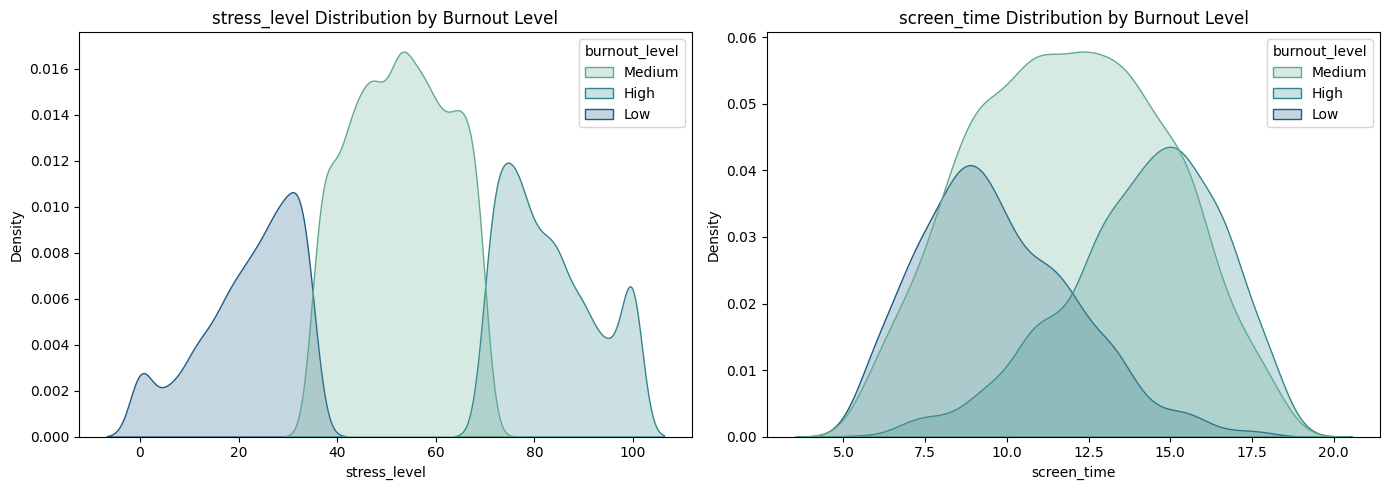

In [33]:
numerical_features = ['stress_level', 'screen_time']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(numerical_features):
    if col in df.columns:
        sns.kdeplot(data=df, x=col, hue=target_col, fill=True, ax=axes[i], palette='crest')
        axes[i].set_title(f'{col} Distribution by Burnout Level')

plt.tight_layout()
plt.show()

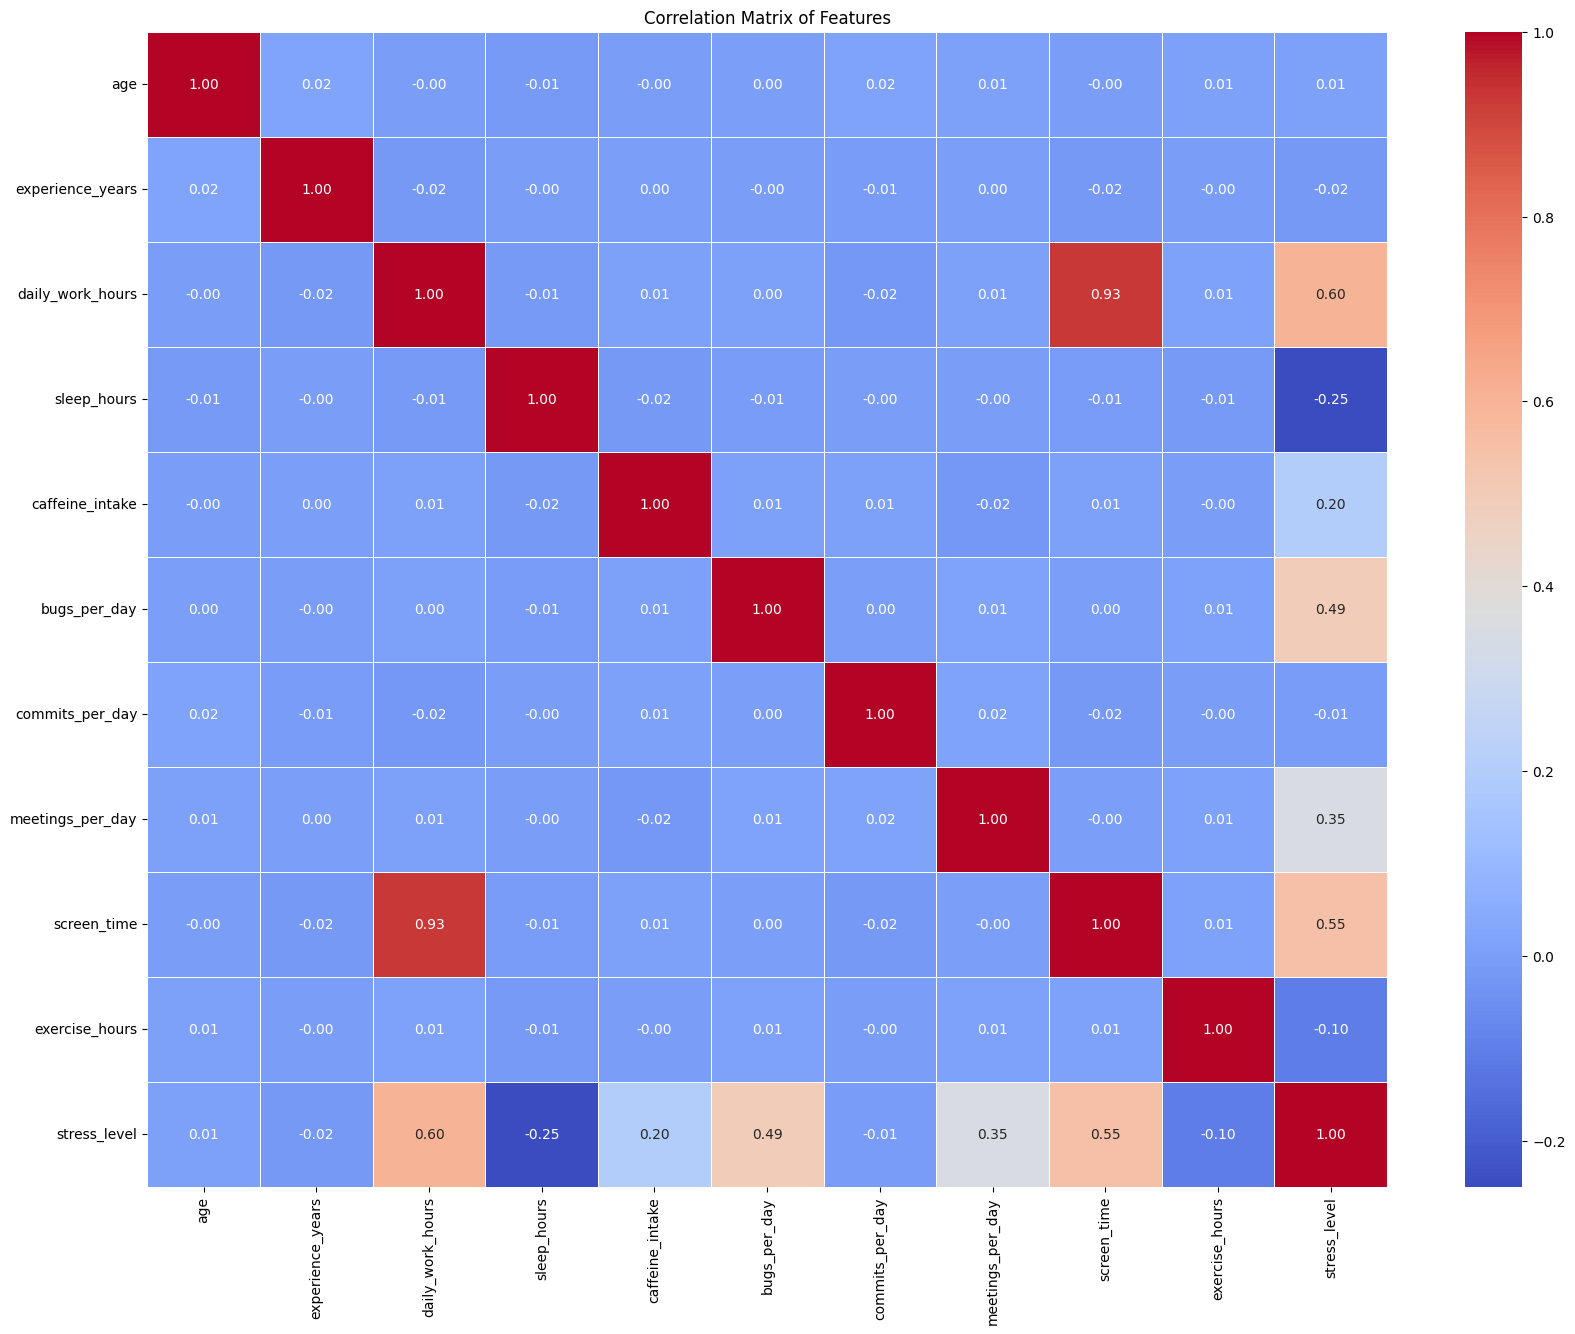

In [34]:
plt.figure(figsize=(20, 15))

num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## Data Preprocessing

Original training target shape: Counter({'Medium': 2788, 'High': 1426, 'Low': 1274})
Resampled training target shape: Counter({'Low': 2788, 'High': 2788, 'Medium': 2788})


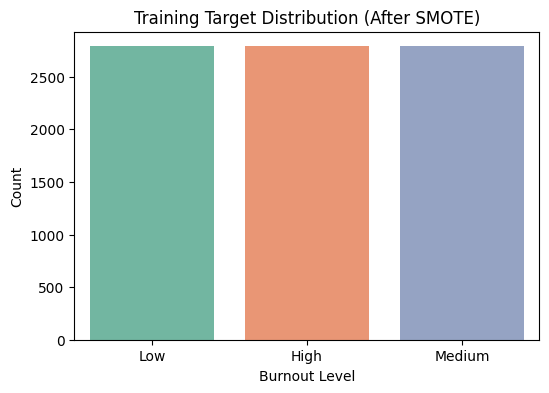

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

if target_col in df.columns:
    df_imputed = df.copy()
    for col in df_imputed.select_dtypes(include=[np.number]).columns:
        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
    
    df_imputed.dropna(subset=[target_col], inplace=True)

    X = df_imputed.drop(columns=[target_col])
    y = df_imputed[target_col]

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Original training target shape: {Counter(y_train)}")
    
    # Balance training set
    smote = SMOTE(random_state=42)

    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled training target shape: {Counter(y_train_resampled)}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_train_resampled, palette='Set2')
    plt.title('Training Target Distribution (After SMOTE)')
    plt.xlabel('Burnout Level')
    plt.ylabel('Count')
    plt.show()